Original Image:


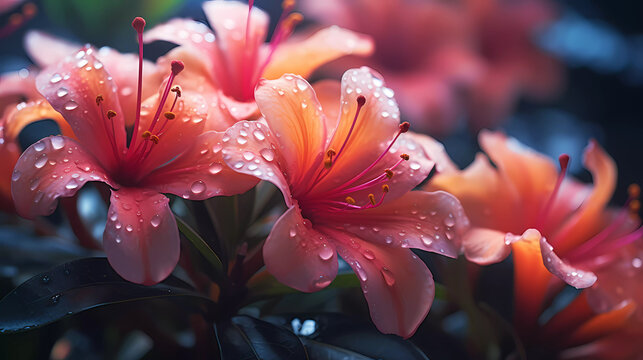


Image with Background Subtracted:


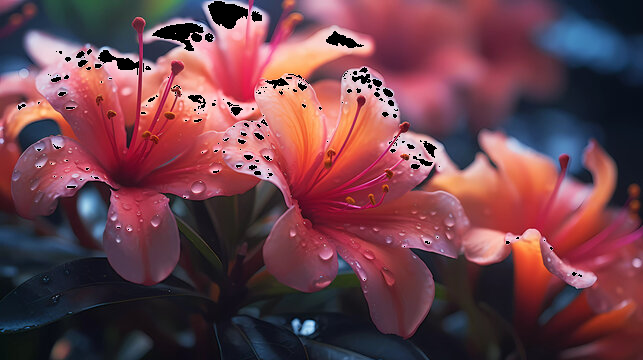

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def subtract_background_by_color(image_path, background_color, threshold=30):
    """
    Subtracts the background of an input image based on color levels.

    Args:
        image_path (str): Path to the input image.
        background_color (tuple): A tuple (B, G, R) representing the background color.
                                 For example, (255, 255, 255) for white background.
        threshold (int): The color difference threshold. Pixels with a difference
                         from the background color less than this threshold will be
                         considered part of the background and made transparent (black).

    Returns:
        numpy.ndarray: The image with the background removed (transparent/black).
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Error: Image not found at {image_path}")

        # Create a background image of the same size as the input image
        bg_image = np.full(img.shape, background_color, dtype=np.uint8)

        # Calculate the absolute difference between the original image and the background color
        # This highlights pixels that are different from the background
        diff = cv2.absdiff(img, bg_image)

        # Convert to grayscale to get a single channel difference value
        gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

        # Threshold the grayscale difference to create a mask
        # Pixels with difference > threshold will be foreground (white)
        # Pixels with difference <= threshold will be background (black)
        _, mask = cv2.threshold(gray_diff, threshold, 255, cv2.THRESH_BINARY)

        # Invert the mask to get the background. We want the foreground to be white
        # The mask will now have white for foreground, black for background
        # mask = cv2.bitwise_not(mask) # Not needed if we use the mask directly

        # Use the mask to extract the foreground from the original image
        # Result will be black where the mask is black (background)
        foreground = cv2.bitwise_and(img, img, mask=mask)

        return foreground

    except FileNotFoundError as e:
        print(e)
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Example Usage (You'll need an image file, e.g., 'sample_image.jpg', in your Colab environment)
# You can upload an image by clicking the folder icon on the left pane -> 'Files' -> 'Upload'

# For demonstration, let's create a dummy image if no file is present
# Or you can replace 'your_image.jpg' with a path to an uploaded image.

# Create a simple dummy image for testing
# Create a black image (background)
blank_image = np.zeros((300, 500, 3), np.uint8)
# Draw a green rectangle (foreground)
cv2.rectangle(blank_image, (50, 50), (200, 250), (0, 255, 0), -1)
# Draw a blue circle (foreground)
cv2.circle(blank_image, (350, 150), 80, (255, 0, 0), -1)

# Save the dummy image (or skip if you're using an uploaded image)
cv2.imwrite('dummy_image.png', blank_image)

# --- MODIFIED PART ---
image_to_process = 'Flower.jpg'

# Define the background color (e.g., black for the dummy image)
# If your image has a white background, use (255, 255, 255)
background_color_to_remove = (255, 255, 255) # Assuming a white background for 'Flower.jpg'

# Perform background subtraction
result_image = subtract_background_by_color(image_to_process, background_color_to_remove, threshold=30)

if result_image is not None:
    print("Original Image:")
    cv2_imshow(cv2.imread(image_to_process))
    print("\nImage with Background Subtracted:")
    cv2_imshow(result_image)
